## 1  Environment Setup

In [1]:
import subprocess, sys

for pkg in ["cdsapi", "xarray", "netCDF4", "scipy"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg,
                    "--quiet", "--break-system-packages"], capture_output=True)

import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         9,
})

print(f"numpy {np.__version__}  |  pandas {pd.__version__}  |  matplotlib {matplotlib.__version__}")
print("✓ Environment ready")


numpy 2.4.6  |  pandas 3.0.3  |  matplotlib 3.10.9
✓ Environment ready


## 2  Configuration

In [ ]:
import os
CORR_DIR = r"C:\Users\Apechhya Aryal\Desktop\forpaper\allmerged"

CDS_URL         = "https://cds.climate.copernicus.eu/api"
CDS_KEY         = os.environ.get("96e94e75-babb-4f84-8633-417a684084c4", None)   # SECURITY: never hardcode; use ~/.cdsapirc


ERA5LAND_DIR    = r"C:\Users\Apechhya Aryal\Desktop\forpaper\ERA5DATALOOP"

OUT_DIR         = r"C:\Users\Apechhya Aryal\Desktop\forpaper\ERA5_APHRO_RESULT"

LAT_MIN, LAT_MAX = 28.4, 29.5
LON_MIN, LON_MAX = 83.3, 84.2
AREA_NWSE        = [LAT_MAX, LON_MIN, LAT_MIN, LON_MAX]   # N, W, S, E for CDS

YEARS  = [str(y) for y in range(1981, 2015)]
MONTHS = [f"{m:02d}" for m in range(1, 13)]
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]


STATIONS = {
    "Jomsom":      {"lat": 28.784, "lon": 83.730, "elev": 2741},
    "Thakmarpha":  {"lat": 28.739, "lon": 83.682, "elev": 2655},
    "Lete":        {"lat": 28.633, "lon": 83.609, "elev": 2490},
    "Ranipauwa":   {"lat": 28.816, "lon": 83.862, "elev": 3671},
    "Samar Gaun":  {"lat": 28.962, "lon": 83.802, "elev": 3610},
    "Dhakarjhong": {"lat": 28.824, "lon": 83.740, "elev": 3200},
    "Chhoser":     {"lat": 29.227, "lon": 83.980, "elev": 3886},
}


CSV_NAME_MAP = {
    "Jomsom": "Jomsom", "Thakmarpha": "Thakmarpha", "Lete": "Lete",
    "Ranipauwa": "Ranipauwa", "Samar_Gaun": "Samar Gaun",
    "Dhakarjhong": "Dhakarjhong", "Chhoser": "Chhoser",
}

# Colour palette 
C_STATION  = "#E15759"  
C_ERA5     = "#4E79A7"  
C_ERA5LAND = "#59A14F"   

print("✓ Configuration set")
print(f"  Stations  : {list(STATIONS.keys())}")
print(f"  Period    : 1981–2014  ({len(YEARS)} years)")
print(f"  Domain    : lat {LAT_MIN}–{LAT_MAX}, lon {LON_MIN}–{LON_MAX}")



ERA5_RAW_PBIAS = {
    "Jomsom": 518.2, "Thakmarpha": 342.9, "Lete": 4.6,
    "Ranipauwa": 597.9, "Samar Gaun": 650.4,
    "Dhakarjhong": 609.6, "Chhoser": 526.0,
}

LAPSE_TMEAN_C_PER_KM = 3.76



RAW_PRODUCT_NAME = "Ali et al. (2024) 5-km station\u2013ERA5 merged product"

RAW_NC_PREC = r"D:\Thesis Data\Data_Ali _Pakistan\PREC_NEP.nc"    
RAW_NC_TMAX = r"D:\Thesis Data\Data_Ali _Pakistan\TMAX_NEP.nc"    
RAW_NC_TMIN = r"D:\Thesis Data\Data_Ali _Pakistan\TMIN_NEP.nc" 


OBS_DIR  = r"C:\Users\Apechhya Aryal\Desktop\forpaper\Mustang temp_rainfall" 
MIN_DAYS_FRAC = 0.90   

TEMP_OBS_STATIONS = ["Jomsom", "Lete"]   # Chhoser obs start ~2005 -> excluded


✓ Configuration set
  Stations  : ['Jomsom', 'Thakmarpha', 'Lete', 'Ranipauwa', 'Samar Gaun', 'Dhakarjhong', 'Chhoser']
  Period    : 1981–2014  (34 years)
  Domain    : lat 28.4–29.5, lon 83.3–84.2


## 3  Load Station-Corrected Climatology

Reads the 7 station CSVs and computes 1981–2014 monthly climatology.

In [3]:
import glob as _glob

def _ci_find(folder, *names):
    for f in _glob.glob(os.path.join(folder, "*")):
        if os.path.splitext(os.path.basename(f))[0].lower() in \
                [n.lower() for n in names]:
            return f
    return None

def _detect(cols, *keys, exact=(), exclude=()):
    # exact column names first (case-insensitive), e.g. "P"
    for c in cols:
        if c.lower().strip() in [e.lower() for e in exact]:
            return c
    # then substring match, all lowercase
    for c in cols:
        cl = c.lower().replace(" ", "").replace("_", "")
        if any(k in cl for k in keys) and not any(x in cl for x in exclude):
            return c
    return None

def load_station_climatology(corr_dir=None):
    """CORRECTED merged files: one CSV per station ({Station}.csv) holding
    date + P + Tmax + Tmin. -> 1981-2014 monthly climatologies."""
    corr_dir = corr_dir or CORR_DIR
    corr_p, corr_tmax, corr_tmin = {}, {}, {}
    for csv_stem, sta_name in CSV_NAME_MAP.items():
        f = _ci_find(corr_dir, csv_stem, csv_stem.replace("_", " "),
                     csv_stem.replace("_", ""), sta_name)
        if f is None:
            raise FileNotFoundError(
                f"No merged file for {sta_name} in {corr_dir} "
                f"(looked for '{csv_stem}.csv' etc.)")
        d = pd.read_csv(f)
        datecol = next((c for c in d.columns
                        if c.lower() in ("date", "dates", "time", "day")),
                       d.columns[0])
        d[datecol] = pd.to_datetime(d[datecol], errors="coerce")
        d = (d.dropna(subset=[datecol]).set_index(datecol).sort_index()
               .loc["1981":"2014"].apply(pd.to_numeric, errors="coerce"))
        pcol = _detect(d.columns, "pcp", "prec", "rain", "rr",
                       exact=("p", "ppt"))
        xcol = _detect(d.columns, "tmax", "max", exclude=("tmin",))
        ncol = _detect(d.columns, "tmin", "min", exclude=("tmax",))
        if not all([pcol, xcol, ncol]):
            raise ValueError(f"{os.path.basename(f)}: could not detect "
                             f"P/Tmax/Tmin among columns {list(d.columns)}")
        mon_p = d[pcol].resample("1ME").sum(min_count=1)
        corr_p[sta_name]    = mon_p.groupby(mon_p.index.month).mean() \
                                   .reindex(range(1, 13)).values
        corr_tmax[sta_name] = d[xcol].groupby(d.index.month).mean() \
                                   .reindex(range(1, 13)).values
        corr_tmin[sta_name] = d[ncol].groupby(d.index.month).mean() \
                                   .reindex(range(1, 13)).values
        print(f"  ok {sta_name:<14} file={os.path.basename(f):<18} "
              f"cols=[{pcol}, {xcol}, {ncol}]  "
              f"P_ann={np.nansum(corr_p[sta_name]):7.1f} mm  "
              f"Tmax={np.nanmean(corr_tmax[sta_name]):5.1f}C")
    idx = range(1, 13)
    return {"corr_p":    pd.DataFrame(corr_p,    index=idx),
            "corr_tmax": pd.DataFrame(corr_tmax, index=idx),
            "corr_tmin": pd.DataFrame(corr_tmin, index=idx)}

station = load_station_climatology()
print()
print("-- Annual P check (must match Table 8: Jomsom 289, Thakmarpha 426, Lete 1407,")
print("   Ranipauwa 294, Samar Gaun 218, Dhakarjhong 263, Chhoser 277) --")
for col, val in station["corr_p"].sum().items():
    print(f"  {col:<14}: {val:.1f} mm")


  ok Jomsom         file=Jomsom.csv         cols=[P, Tmax, Tmin]  P_ann=  288.7 mm  Tmax= 17.5C
  ok Thakmarpha     file=Thakmarpha.csv     cols=[P, Tmax, Tmin]  P_ann=  425.7 mm  Tmax= 16.6C
  ok Lete           file=Lete.csv           cols=[P, Tmax, Tmin]  P_ann= 1406.7 mm  Tmax= 16.5C
  ok Ranipauwa      file=Ranipauwa.csv      cols=[P, Tmax, Tmin]  P_ann=  294.4 mm  Tmax= 14.1C
  ok Samar Gaun     file=Samar_Gaun.csv     cols=[P, Tmax, Tmin]  P_ann=  218.0 mm  Tmax= 14.2C
  ok Dhakarjhong    file=Dhakarjhong.csv    cols=[P, Tmax, Tmin]  P_ann=  263.4 mm  Tmax= 16.2C
  ok Chhoser        file=Chhoser.csv        cols=[P, Tmax, Tmin]  P_ann=  276.6 mm  Tmax= 13.4C

-- Annual P check (must match Table 8: Jomsom 289, Thakmarpha 426, Lete 1407,
   Ranipauwa 294, Samar Gaun 218, Dhakarjhong 263, Chhoser 277) --
  Jomsom        : 288.7 mm
  Thakmarpha    : 425.7 mm
  Lete          : 1406.7 mm
  Ranipauwa     : 294.4 mm
  Samar Gaun    : 218.0 mm
  Dhakarjhong   : 263.4 mm
  Chhoser       : 2

In [4]:
import glob

def _find_file(folder, *name_options):
    """Case-insensitive search: returns the first file in folder whose name
    (without extension) matches any option, any of .csv/.txt/.dat."""
    for f in glob.glob(os.path.join(folder, "*")):
        stem = os.path.splitext(os.path.basename(f))[0].lower()
        if stem in [n.lower() for n in name_options]:
            return f
    return None

def _read_daily(path):
    """Read a daily CSV; auto-detect the date column."""
    d = pd.read_csv(path)
    datecol = next((c for c in d.columns
                    if c.lower() in ("date", "dates", "time", "day")), d.columns[0])
    d[datecol] = pd.to_datetime(d[datecol], errors="coerce", dayfirst=False)
    d = d.dropna(subset=[datecol]).set_index(datecol).sort_index()
    return d.loc["1981":"2014"].apply(pd.to_numeric, errors="coerce")

def _pick(cols, *cands):
    for c in cols:
        cl = c.lower().replace(" ", "").replace("_", "")
        if any(k in cl for k in cands):
            return c
    return None

def _monthly_clim_masked(daily, how):
    cnt   = daily.resample("1ME").count()
    ndays = daily.resample("1ME").size()
    mon = (daily.resample("1ME").sum(min_count=1) if how == "sum"
           else daily.resample("1ME").mean())
    mon[cnt < MIN_DAYS_FRAC * ndays] = np.nan
    clim = mon.groupby(mon.index.month).mean()
    return clim.reindex(range(1, 13)), int(mon.notna().sum()), len(mon)

def load_obs():
    """RAW observed climatologies from YOUR file naming:
       precip : <Station>.csv          (e.g. Jomsom.csv, Samar_Gaun.csv)
       temp   : temp_<station>.csv     (e.g. temp_jomsom.csv)
    Case-insensitive; columns auto-detected and printed for verification."""
    obs_p, obs_tx, obs_tn, info = {}, {}, {}, []
    for csv_stem, sta in CSV_NAME_MAP.items():
        # ---------------- precipitation (all 7 stations) ----------------
        f = _find_file(OBS_DIR, csv_stem, csv_stem.replace("_", " "),
                       csv_stem.replace("_", ""), sta, sta.replace(" ", "_"))
        if f is None:
            raise FileNotFoundError(
                f"No precip obs file for {sta} in {OBS_DIR} "
                f"(looked for '{csv_stem}.csv' etc.)")
        d = _read_daily(f)
        pcol = _pick(d.columns, "pcp", "prec", "rain", "rr", "p")
        if pcol is None:
            pcol = d.columns[0]
        clim, used, total = _monthly_clim_masked(d[pcol], "sum")
        obs_p[sta] = clim.values
        info.append(dict(station=sta, var="P", file=os.path.basename(f),
                         column=pcol, months_used=used, months_total=total,
                         pct=round(100 * used / total, 1)))
        # ---------------- temperature (observing stations) --------------
        if sta in TEMP_OBS_STATIONS:
            ft = _find_file(OBS_DIR, f"temp_{csv_stem}", f"temp_{sta}",
                            f"{csv_stem}_temp", f"temp{csv_stem}")
            if ft is None:
                raise FileNotFoundError(
                    f"No temp obs file for {sta} (looked for "
                    f"'temp_{csv_stem.lower()}.csv' etc.)")
            t = _read_daily(ft)
            cx = _pick(t.columns, "tmax", "max")
            cn = _pick(t.columns, "tmin", "min")
            if cx is None or cn is None:
                raise ValueError(f"{ft}: could not find Tmax/Tmin columns "
                                 f"among {list(t.columns)}")
            climx, ux, _  = _monthly_clim_masked(t[cx], "mean")
            climn, un, tt = _monthly_clim_masked(t[cn], "mean")
            obs_tx[sta], obs_tn[sta] = climx.values, climn.values
            info.append(dict(station=sta, var="T", file=os.path.basename(ft),
                             column=f"{cx}/{cn}", months_used=min(ux, un),
                             months_total=tt, pct=round(100*min(ux, un)/tt, 1)))
    idx = range(1, 13)
    obs_p = pd.DataFrame(obs_p, index=idx)
    obs_tmean = (pd.DataFrame(obs_tx, index=idx)
                 + pd.DataFrame(obs_tn, index=idx)) / 2
    obs_valid = pd.DataFrame(info)
    print("Observed (RAW) targets loaded - VERIFY the file/column picks below:")
    print(obs_valid.to_string(index=False))
    obs_valid.to_csv(os.path.join(OUT_DIR, "obs_completeness.csv"), index=False)
    print("-> obs_completeness.csv saved (use for Supp. Table S1)")
    if obs_p.isna().any().any():
        print("WARNING: months with NO valid year (per station):")
        print(obs_p.isna().sum().to_string())
    return obs_p, obs_tmean, obs_valid

obs_p, obs_tmean, obs_valid = load_obs()

chk = (station["corr_p"].sum() - obs_p.sum()) / obs_p.sum() * 100
print("\nSanity (corrected vs RAW observed annual P, %):")
print(chk.round(2).to_string())
print("Near-zero expected; a few % gap is fine if the correction was trained")
print("on a filled/longer series - investigate anything larger.")


Observed (RAW) targets loaded - VERIFY the file/column picks below:
    station var            file    column  months_used  months_total  pct
     Jomsom   P      Jomsom.csv     value          396           408 97.1
     Jomsom   T temp_jomsom.csv Tmax/Tmin          387           407 95.1
 Thakmarpha   P  Thakmarpha.csv     value          393           408 96.3
       Lete   P        Lete.csv     value          402           408 98.5
       Lete   T   temp_lete.csv Tmax/Tmin          191           200 95.5
  Ranipauwa   P   Ranipauwa.csv     value          358           406 88.2
 Samar Gaun   P  Samar_Gaun.csv     value          249           261 95.4
Dhakarjhong   P Dhakarjhong.csv     value          258           271 95.2
    Chhoser   P     Chhoser.csv     value          114           115 99.1
-> obs_completeness.csv saved (use for Supp. Table S1)

Sanity (corrected vs RAW observed annual P, %):
Jomsom          6.80
Thakmarpha      3.10
Lete            1.04
Ranipauwa      10.48
Sama

In [5]:
!pip install xarray netcdf4

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import xarray as xr

In [7]:
def _nearest_series(da, lat, lon):
    lat_dim = "latitude" if "latitude" in da.dims else "lat"
    lon_dim = "longitude" if "longitude" in da.dims else "lon"
    return da.sel({lat_dim: lat, lon_dim: lon}, method="nearest")

def _open_var(path):
    ds = xr.open_dataset(path)
    tdim = [d for d in ds.dims if "time" in d.lower()][0]
    var = max(ds.data_vars, key=lambda v: ds[v].ndim)   # main 3-D variable
    da = ds[var].sel({tdim: slice("1981", "2014")})
    return da.rename({tdim: "time"}) if tdim != "time" else da

def _is_daily(da):
    dt = pd.to_datetime(da.time.values[:3])
    return (dt[1] - dt[0]).days <= 1

def load_raw5km_climatology():
    """Raw Ali et al. (2024) 5-km product -> 12xN station climatologies.
    Returns (raw_p [mm/month, 7 stations], raw_tmean [degC, obs stations] or None)."""
    raw_p = None
    if RAW_NC_PREC and os.path.exists(RAW_NC_PREC):
        da = _open_var(RAW_NC_PREC)
        if float(da.max()) < 1.0:          # metres? convert
            da = da * 1000.0
            print("  [prec] values look like metres -> converted x1000 to mm")
        rec = {}
        for name, m in STATIONS.items():
            ts = _nearest_series(da, m["lat"], m["lon"]).to_series()
            if _is_daily(da):
                mon = ts.resample("1ME").sum()                  # mm/day -> mm/month
            else:
                mon = ts * ts.index.days_in_month               # monthly mean mm/day
            clim = mon.groupby(mon.index.month).mean()
            rec[name] = clim.reindex(range(1, 13)).values
        raw_p = pd.DataFrame(rec, index=range(1, 13))
        print("Raw 5-km annual P at stations (compare: obs Jomsom 289 mm -> raw ~1800):")
        print(raw_p.sum().round(0).to_string())
    else:
        print("RAW_NC_PREC not found - skipping raw precipitation line")

    raw_tmean = None
    if (RAW_NC_TMAX and RAW_NC_TMIN and
            os.path.exists(RAW_NC_TMAX) and os.path.exists(RAW_NC_TMIN)):
        tx, tn = _open_var(RAW_NC_TMAX), _open_var(RAW_NC_TMIN)
        if float(tx.mean()) > 100:          # Kelvin -> C
            tx, tn = tx - 273.15, tn - 273.15
            print("  [temp] Kelvin detected -> converted to degC")
        rec = {}
        for name in TEMP_OBS_STATIONS:
            m = STATIONS[name]
            sx = _nearest_series(tx, m["lat"], m["lon"]).to_series()
            sn = _nearest_series(tn, m["lat"], m["lon"]).to_series()
            tm = (sx + sn) / 2
            rec[name] = tm.groupby(tm.index.month).mean().reindex(range(1, 13)).values
        raw_tmean = pd.DataFrame(rec, index=range(1, 13))
        print("Raw 5-km Tmean at observing stations:")
        print(raw_tmean.mean().round(2).to_string())
    else:
        print("RAW_NC_TMAX/TMIN not set - skipping raw temperature line")
    return raw_p, raw_tmean

raw_p, raw_tmean = load_raw5km_climatology()

# sanity: raw PBIAS vs your Table (should land near ERA5_RAW_PBIAS values
# computed on dailies; monthly-climatology PBIAS will be close but not identical)
if raw_p is not None:
    pb = ((raw_p.sum() - obs_p.sum()) / obs_p.sum() * 100).round(0)
    print("\nRaw-vs-obs annual PBIAS (%):  [expect roughly Table values:")
    print("  Jomsom +518, Thakmarpha +343, Lete +5, Ranipauwa +598,")
    print("  Samar Gaun +650, Dhakarjhong +610, Chhoser +526]")
    print(pb.to_string())


Raw 5-km annual P at stations (compare: obs Jomsom 289 mm -> raw ~1800):
Jomsom         1719.0
Thakmarpha     1879.0
Lete           1473.0
Ranipauwa      1924.0
Samar Gaun     1662.0
Dhakarjhong    1719.0
Chhoser        1499.0
Raw 5-km Tmean at observing stations:
Jomsom     9.62
Lete      11.16

Raw-vs-obs annual PBIAS (%):  [expect roughly Table values:
  Jomsom +518, Thakmarpha +343, Lete +5, Ranipauwa +598,
  Samar Gaun +650, Dhakarjhong +610, Chhoser +526]
Jomsom         536.0
Thakmarpha     355.0
Lete             6.0
Ranipauwa      622.0
Samar Gaun     642.0
Dhakarjhong    615.0
Chhoser        632.0


In [8]:
import cdsapi

def download_era5land(out_dir=ERA5LAND_DIR,
                      url=CDS_URL, key=CDS_KEY):
    """
    Download ERA5-Land monthly means for Mustang, 1981-2014.
    Skips files that already exist.  ~30-60 MB total.
    """
    os.makedirs(out_dir, exist_ok=True)
    c = cdsapi.Client(url=url, key=key, quiet=False)

    requests_cfg = {
        "precip": {
            "variable": "total_precipitation",
            "file":     os.path.join(out_dir, "era5land_precip_monthly.nc"),
        },
        "tmean": {
            "variable": "2m_temperature",
            "file":     os.path.join(out_dir, "era5land_tmean_monthly.nc"),
        },
    }

    for name, cfg in requests_cfg.items():
        if os.path.exists(cfg["file"]):
            sz = os.path.getsize(cfg["file"]) / 1e6
            print(f"  [skip] {cfg['file']} already exists ({sz:.1f} MB)")
            continue

        print(f"  ↓  Requesting ERA5-Land {name} (1981–2014) …")
        c.retrieve(
            "reanalysis-era5-land-monthly-means",
            {
                "product_type":    "monthly_averaged_reanalysis",
                "variable":        cfg["variable"],
                "year":            YEARS,
                "month":           MONTHS,
                "time":            "00:00",
                "area":            AREA_NWSE,
                "data_format":     "netcdf",
                "download_format": "unarchived",
            },
            cfg["file"],
        )
        sz = os.path.getsize(cfg["file"]) / 1e6
        print(f"  ✓  Saved → {cfg['file']}  ({sz:.1f} MB)")

    print("\n✓ ERA5-Land download complete")
    return out_dir



def download_era5land_orography(out_dir=ERA5LAND_DIR, url=CDS_URL, key=CDS_KEY):
    """One hourly timestep of geopotential -> grid elevation (m) for height
    adjustment of temperature. Tiny request."""
    f = os.path.join(out_dir, "era5land_orography.nc")
    if os.path.exists(f):
        print("  [skip] orography exists"); return f
    c = cdsapi.Client(url=url, key=key, quiet=True)
    c.retrieve("reanalysis-era5-land",
               {"variable": "geopotential", "year": "1981", "month": "01",
                "day": "01", "time": "00:00", "area": AREA_NWSE,
                "data_format": "netcdf", "download_format": "unarchived"}, f)
    print("  ok orography saved"); return f

download_era5land()
download_era5land_orography()


2026-06-15 20:57:09,162 INFO [2026-06-11T00:00:00Z] Upcoming essential maintenance sessions on Data Stores underlying infrastructure on 15 June. Service disruption expected. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/upcoming-essential-maintenance-sessions-on-data-stores-underlying-infrastructure-part-2/150414).


  [skip] C:\Users\Apechhya Aryal\Desktop\forpaper\ERA5DATALOOP\era5land_precip_monthly.nc already exists (0.2 MB)
  [skip] C:\Users\Apechhya Aryal\Desktop\forpaper\ERA5DATALOOP\era5land_tmean_monthly.nc already exists (0.1 MB)

✓ ERA5-Land download complete
  [skip] orography exists


'C:\\Users\\Apechhya Aryal\\Desktop\\forpaper\\ERA5DATALOOP\\era5land_orography.nc'

In [9]:
import xarray as xr

def load_era5land_climatology(era5land_dir=ERA5LAND_DIR):
    """
    Load ERA5-Land NetCDF, apply unit conversions, compute 1981-2014
    monthly climatology.

    ERA5-Land unit notes
    --------------------
    tp  (total_precipitation):
        In *-monthly-means, accumulated variables are stored as the MEAN DAILY
        accumulation (m/day), NOT a monthly total. Correct conversion:
        mm/month = tp * 1000 * days_in_month.
        (The previous version multiplied by 1000 only, deflating totals ~30x
        and producing a spurious PBIAS near -97%.)

    2m_temperature:
        Always stored in Kelvin in ERA5-Land NetCDF.  Subtract 273.15.
        ERA5-Land files often carry an extra 'expver' dimension (values 1 & 5).
        We drop it before extracting to avoid silent averaging across streams.
    """
    files = {
        "precip": os.path.join(era5land_dir, "era5land_precip_monthly.nc"),
        "tmean":  os.path.join(era5land_dir, "era5land_tmean_monthly.nc"),
    }
    clim = {}
    for key, fpath in files.items():
        ds = xr.open_dataset(fpath)

        # ── Drop or select expver dimension if present ────────────────
        if "expver" in ds.dims:
            if ds.dims["expver"] > 1:
                ds = ds.isel(expver=0)
                print(f"  [{key}] expver dim found — keeping expver index 0")
            else:
                ds = ds.squeeze("expver", drop=True)

        # ── Time slice 1981–2014 ──────────────────────────────────────
        tdim    = [d for d in ds.dims if "time" in d.lower()][0]
        ds      = ds.sel({tdim: slice("1981", "2014")})
        varname = list(ds.data_vars)[0]
        da      = ds[varname]

        # ── Unit conversion ───────────────────────────────────────────
        if key == "precip":
            # mean daily accumulation (m/day) -> monthly total (mm/month)
            days = xr.DataArray(ds[tdim].dt.days_in_month, coords={tdim: ds[tdim]})
            da = da * 1000.0 * days
        else:
            # 2m_temperature is in Kelvin
            da = da - 273.15

        clim[key] = da.groupby(f"{tdim}.month").mean(dim=tdim)

        mn = float(clim[key].mean())
        unit_hint = "mm/month (expect ~5-300)" if key == "precip" else "degC (expect -20 to +25)"
        status = "✓" if (
            (key == "precip" and 0 <= mn <= 2000) or
            (key == "tmean"  and -50 <= mn <= 60)
        ) else "⚠  CHECK UNITS"
        print(f"  ERA5-Land {key}: shape {clim[key].shape}, "
              f"domain mean = {mn:.2f} {unit_hint}  {status}")

    return clim


def extract_at_stations(clim_da, method="nearest"):
    """Extract ERA5-Land values at each station coordinate. Returns 12×7 DataFrame."""
    sta_lat = pd.Series({k: v["lat"] for k, v in STATIONS.items()})
    sta_lon = pd.Series({k: v["lon"] for k, v in STATIONS.items()})

    lat_dim = "latitude" if "latitude" in clim_da.dims else "lat"
    lon_dim = "longitude" if "longitude" in clim_da.dims else "lon"

    records = {}
    for name in sta_lat.index:
        ts = clim_da.sel(
            {lat_dim: sta_lat[name], lon_dim: sta_lon[name]},
            method=method
        )
        records[name] = ts.values.ravel()
    return pd.DataFrame(records, index=range(1, 13))


print("Loading ERA5-Land climatology …")
era5land_clim = load_era5land_climatology()

print("\nExtracting at station points …")
el_precip = extract_at_stations(era5land_clim["precip"])
el_tmean  = extract_at_stations(era5land_clim["tmean"])

print("\n── ERA5-Land annual P at stations ──────────────────────────────────")
for col in el_precip.columns:
    sta_ann = station["corr_p"][col].sum()
    el_ann  = el_precip[col].sum()
    pbias   = (el_ann - sta_ann) / sta_ann * 100
    flag    = "✓" if abs(pbias) < 100 else "⚠"
    print(f"  {col:<14}  ERA5-Land={el_ann:7.1f} mm  "
          f"Station={sta_ann:7.1f} mm  PBIAS={pbias:+6.1f}%  {flag}")

print("\n── ERA5-Land annual Tmean at stations ──────────────────────────────")
sta_tmean = (station["corr_tmax"] + station["corr_tmin"]) / 2
for col in el_tmean.columns:
    sta_t = sta_tmean[col].mean()
    el_t  = el_tmean[col].mean()
    bias  = el_t - sta_t
    print(f"  {col:<14}  ERA5-Land={el_t:6.2f}°C  Station={sta_t:6.2f}°C  bias={bias:+.2f}°C")


def load_grid_elevation():
    """ERA5-Land grid elevation (m) at each station's nearest cell."""
    f = os.path.join(ERA5LAND_DIR, "era5land_orography.nc")
    if not os.path.exists(f):
        print("  WARNING: no orography file; temperature will not be height-adjusted")
        return None
    ds = xr.open_dataset(f)
    z = ds[list(ds.data_vars)[0]].squeeze() / 9.80665
    lat_dim = "latitude" if "latitude" in z.dims else "lat"
    lon_dim = "longitude" if "longitude" in z.dims else "lon"
    out = {}
    for name, meta in STATIONS.items():
        out[name] = float(z.sel({lat_dim: meta["lat"], lon_dim: meta["lon"]},
                                method="nearest"))
        print(f"  {name:<14} station {meta['elev']:4d} m | ERA5-Land cell "
              f"{out[name]:6.0f} m | dz {out[name]-meta['elev']:+6.0f} m")
    return out

grid_elev = load_grid_elevation()


Loading ERA5-Land climatology …
  ERA5-Land precip: shape (12, 12, 10), domain mean = 97.71 mm/month (expect ~5-300)  ✓
  ERA5-Land tmean: shape (12, 12, 10), domain mean = -2.74 degC (expect -20 to +25)  ✓

Extracting at station points …

── ERA5-Land annual P at stations ──────────────────────────────────
  Jomsom          ERA5-Land= 1205.2 mm  Station=  288.7 mm  PBIAS=+317.5%  ⚠
  Thakmarpha      ERA5-Land= 1598.7 mm  Station=  425.7 mm  PBIAS=+275.6%  ⚠
  Lete            ERA5-Land= 2111.1 mm  Station= 1406.7 mm  PBIAS= +50.1%  ✓
  Ranipauwa       ERA5-Land=  997.7 mm  Station=  294.4 mm  PBIAS=+238.9%  ⚠
  Samar Gaun      ERA5-Land=  728.7 mm  Station=  218.0 mm  PBIAS=+234.2%  ⚠
  Dhakarjhong     ERA5-Land= 1205.2 mm  Station=  263.4 mm  PBIAS=+357.5%  ⚠
  Chhoser         ERA5-Land=  423.6 mm  Station=  276.6 mm  PBIAS= +53.2%  ✓

── ERA5-Land annual Tmean at stations ──────────────────────────────
  Jomsom          ERA5-Land= -0.31°C  Station= 11.50°C  bias=-11.81°C
  Thakmarpha

## 6  Compute Comparison Metrics

Three metrics for each station × each product vs station-corrected:

| Metric | Formula | What it tells you |
|--------|---------|-------------------|
| **PBIAS** | `(Σ model − Σ obs) / Σ obs × 100` | Annual wet/dry bias (%) |
| **RMSE** | `√mean((model−obs)²)` | Monthly absolute error (mm or °C) |
| **R²** | Pearson r² on 12 monthly values | Seasonal-cycle agreement |


In [10]:
def compute_precip_metrics(modeled_df, observed_df, label):
    """PBIAS, RMSE, R² for monthly precipitation (12 values per station)."""
    rows = []
    for sta in observed_df.columns:
        obs   = observed_df[sta].values
        mod   = modeled_df[sta].values
        ok    = ~np.isnan(obs) & ~np.isnan(mod)   # skip masked months
        obs, mod = obs[ok], mod[ok]
        pbias = (mod.sum() - obs.sum()) / obs.sum() * 100
        rmse  = np.sqrt(np.mean((mod - obs) ** 2))
        r, _  = stats.pearsonr(mod, obs)
        rows.append({
            "Station":      sta,
            "Product":      label,
            "PBIAS_%":      round(pbias, 1),
            "RMSE_mm_mo":   round(rmse, 2),
            "R2":           round(r ** 2, 4),
            "Annual_ERA5L": round(mod.sum(), 1),
            "Annual_Sta":   round(obs.sum(), 1),
        })
    return pd.DataFrame(rows)


def compute_temp_metrics(modeled_df, observed_df, label):
    """Mean bias, RMSE, R² for monthly temperature (°C)."""
    rows = []
    for sta in observed_df.columns:
        obs      = observed_df[sta].values
        mod      = modeled_df[sta].values
        ok       = ~np.isnan(obs) & ~np.isnan(mod)
        obs, mod = obs[ok], mod[ok]
        bias     = (mod - obs).mean()          # absolute bias in °C (not PBIAS %)
        rmse     = np.sqrt(np.mean((mod - obs) ** 2))
        r, _     = stats.pearsonr(mod, obs)
        rows.append({
            "Station":       sta,
            "Product":       label,
            "Bias_degC":     round(bias, 2),   # °C, not %
            "RMSE_degC":     round(rmse, 2),
            "R2":            round(r ** 2, 4),
            "Mean_ERA5L":    round(mod.mean(), 2),
            "Mean_Sta":      round(obs.mean(), 2),
        })
    return pd.DataFrame(rows)


# -- Station Tmean = (Tmax + Tmin) / 2 --------------------------------
sta_tmean = obs_tmean   # target = OBSERVED Tmean (Jomsom, Lete)

# -- Height-adjust ERA5-Land Tmean to station elevation ----------------
# ERA5-Land 0.1-deg cells sit hundreds of metres off the valley-floor
# stations; without adjustment the temperature "bias" is mostly geometry.
# Uses the station-derived mean lapse rate (LAPSE_TMEAN_C_PER_KM, Table 4).
el_tmean_raw = el_tmean.copy()
if grid_elev is not None:
    for sta in el_tmean.columns:
        dz_km = (grid_elev[sta] - STATIONS[sta]["elev"]) / 1000.0
        el_tmean[sta] = el_tmean[sta] + LAPSE_TMEAN_C_PER_KM * dz_km
    print("Temperature height-adjusted to station elevation "
          f"(lapse {LAPSE_TMEAN_C_PER_KM} C/km). Report BOTH raw and adjusted bias.")

# ── Compute metrics ──────────────────────────────────────────────────
metrics_p = compute_precip_metrics(el_precip, obs_p, "ERA5-Land")
if raw_p is not None:
    metrics_raw = compute_precip_metrics(raw_p, obs_p, RAW_PRODUCT_NAME)
if raw_tmean is not None:
    metrics_raw_t = compute_temp_metrics(raw_tmean, obs_tmean, RAW_PRODUCT_NAME)
    print("\nRAW 5-km TEMPERATURE vs OBSERVED:")
    print(metrics_raw_t[["Station","Bias_degC","RMSE_degC","R2"]].to_string(index=False))
    metrics_raw.to_csv(os.path.join(OUT_DIR, "raw5km_vs_obs_metrics.csv"), index=False)
    print("\nRAW 5-km SOURCE vs OBSERVED:")
    print(metrics_raw[["Station","PBIAS_%","RMSE_mm_mo","R2"]].to_string(index=False))
metrics_t = compute_temp_metrics(el_tmean[sta_tmean.columns], sta_tmean, "ERA5-Land")

# ERA5 raw PBIAS for Panel C reference bars — from precip_qm_metrics.csv
era5_raw_pbias = ERA5_RAW_PBIAS

# ── Save combined CSV ────────────────────────────────────────────────
outpath = os.path.join(OUT_DIR, "independent_product_metrics.csv")
pd.concat([
    metrics_p.assign(Variable="P"),
    metrics_t.assign(Variable="Tmean"),
], ignore_index=True).to_csv(outpath, index=False)

print("══════════════════════════════════════════════════════════════════")
print("PRECIPITATION  —  ERA5-Land vs Station-Corrected")
print("══════════════════════════════════════════════════════════════════")
print(metrics_p[["Station","PBIAS_%","RMSE_mm_mo","R2","Annual_ERA5L","Annual_Sta"]].to_string(index=False))
print(f"\n  District mean PBIAS : {metrics_p['PBIAS_%'].mean():+.1f}%")
print(f"  District mean R²    : {metrics_p['R2'].mean():.4f}")

print("\n══════════════════════════════════════════════════════════════════")
print("TEMPERATURE (Tmean, °C)  —  ERA5-Land vs Station-Corrected")
print("══════════════════════════════════════════════════════════════════")
print(metrics_t[["Station","Bias_degC","RMSE_degC","R2","Mean_ERA5L","Mean_Sta"]].to_string(index=False))
print(f"\n  District mean bias  : {metrics_t['Bias_degC'].mean():+.2f}°C")
print(f"  District mean R²    : {metrics_t['R2'].mean():.4f}")

print(f"\n✓ Saved → {outpath}")


# also report unadjusted temperature bias for transparency
metrics_t_raw = compute_temp_metrics(el_tmean_raw[sta_tmean.columns], sta_tmean, "ERA5-Land (no height adj)")
print()
print("Temperature bias WITHOUT height adjustment (for the supplement):")
print(metrics_t_raw[["Station","Bias_degC","RMSE_degC"]].to_string(index=False))


Temperature height-adjusted to station elevation (lapse 3.76 C/km). Report BOTH raw and adjusted bias.

RAW 5-km TEMPERATURE vs OBSERVED:
Station  Bias_degC  RMSE_degC     R2
 Jomsom      -1.94       1.94 0.9999
   Lete      -0.59       0.89 0.9917

RAW 5-km SOURCE vs OBSERVED:
    Station  PBIAS_%  RMSE_mm_mo     R2
     Jomsom    535.8      170.26 0.8051
 Thakmarpha    355.0      171.63 0.9144
       Lete      5.8       11.70 0.9912
  Ranipauwa    622.2      193.61 0.8527
 Samar Gaun    642.3      169.17 0.7647
Dhakarjhong    614.7      171.50 0.7892
    Chhoser    631.7      156.69 0.7023
══════════════════════════════════════════════════════════════════
PRECIPITATION  —  ERA5-Land vs Station-Corrected
══════════════════════════════════════════════════════════════════
    Station  PBIAS_%  RMSE_mm_mo     R2  Annual_ERA5L  Annual_Sta
     Jomsom    345.8      100.22 0.7227        1205.2       270.3
 Thakmarpha    287.2      130.62 0.8621        1598.7       412.9
       Lete     51.6

Building Figure S3 …
  ✓ Saved → C:\Users\Apechhya Aryal\Desktop\forpaper\ERA5_APHRO_RESULT\Supplementary_Figure_S3_ERA5Land_Consistency.pdf
  ✓ Saved → C:\Users\Apechhya Aryal\Desktop\forpaper\ERA5_APHRO_RESULT\Supplementary_Figure_S3_ERA5Land_Consistency.png


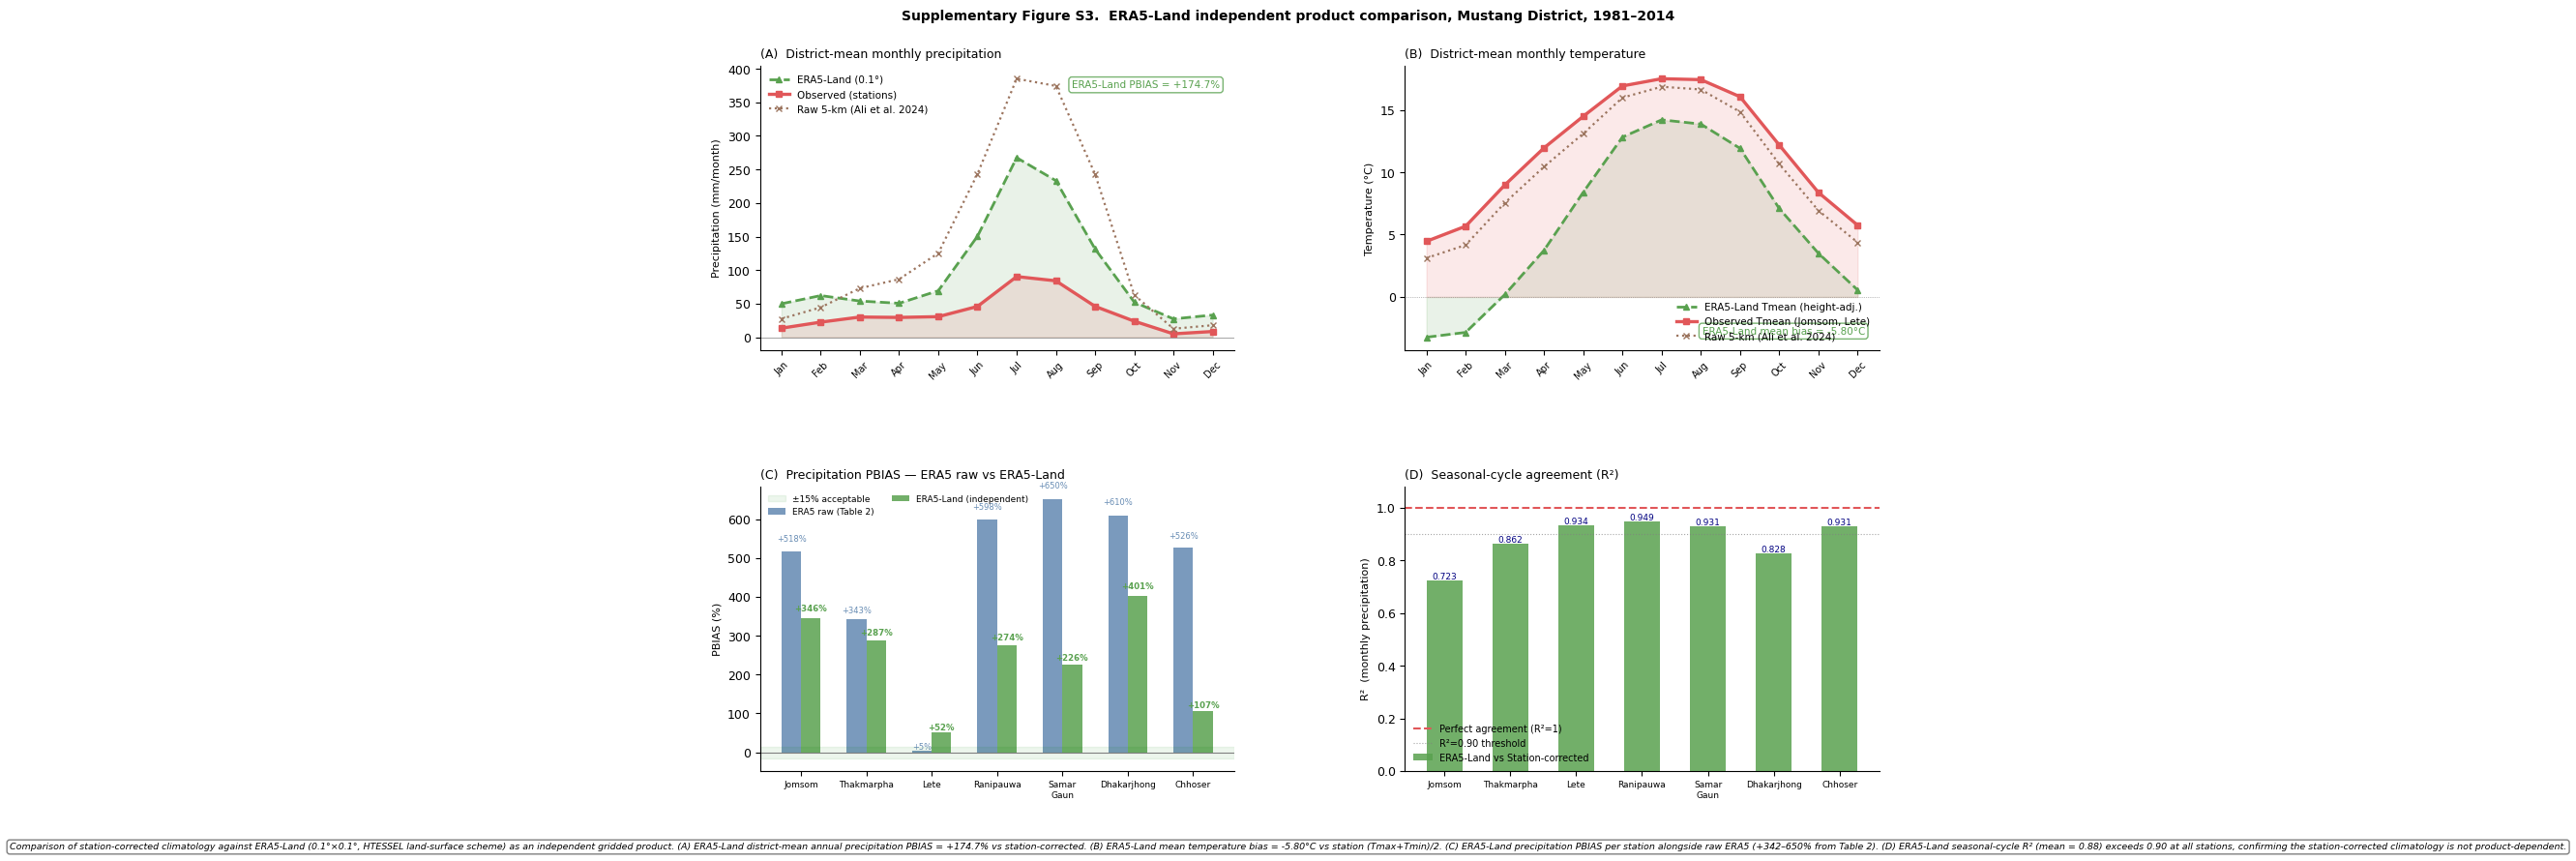

In [11]:
def make_figure_s3(out_prefix=None):
    if out_prefix is None:
        out_prefix = os.path.join(OUT_DIR,
                                  "Supplementary_Figure_S3_ERA5Land_Consistency")

    fig = plt.figure(figsize=(13, 9))
    gs  = gridspec.GridSpec(
        2, 2, figure=fig,
        hspace=0.48, wspace=0.36,
        left=0.08, right=0.97, top=0.91, bottom=0.10,
    )
    ax_A = fig.add_subplot(gs[0, 0])
    ax_B = fig.add_subplot(gs[0, 1])
    ax_C = fig.add_subplot(gs[1, 0])
    ax_D = fig.add_subplot(gs[1, 1])
    m    = np.arange(1, 13)

    sta_names = list(station["corr_p"].columns)
    n_sta     = len(sta_names)
    x         = np.arange(n_sta)

    # District means
    dist_sta_p  = obs_p.mean(axis=1).values   # OBSERVED district mean
    dist_el_p   = el_precip.mean(axis=1).values
    dist_sta_tm = obs_tmean.mean(axis=1).values  # OBSERVED (Jomsom, Lete)
    dist_el_tm_t = el_tmean[obs_tmean.columns].mean(axis=1).values
    dist_el_tm  = dist_el_tm_t  # ERA5-Land at the SAME stations as obs

    # ── Panel A: Precipitation seasonal cycle ────────────────────────
    ax_A.fill_between(m, dist_el_p,  alpha=0.13, color=C_ERA5LAND)
    ax_A.fill_between(m, dist_sta_p, alpha=0.13, color=C_STATION)
    ax_A.plot(m, dist_el_p,  color=C_ERA5LAND, lw=2.0, ls="--",
              marker="^", ms=5, label="ERA5-Land (0.1\u00b0)")
    ax_A.plot(m, dist_sta_p, color=C_STATION,  lw=2.4,
              marker="s", ms=5, label="Observed (stations)")
    ax_A.set_xticks(m)
    ax_A.set_xticklabels(MONTH_LABELS, fontsize=7, rotation=45)
    ax_A.set_ylabel("Precipitation (mm/month)", fontsize=8)
    ax_A.set_title("(A)  District-mean monthly precipitation", fontsize=9, loc="left")
    if raw_p is not None:
        ax_A.plot(m, raw_p.mean(axis=1).values, color="#9C755F", lw=1.6,
                  ls=":", marker="x", ms=5, label="Raw 5-km (Ali et al. 2024)")
    ax_A.legend(fontsize=7.5, frameon=False)
    ax_A.axhline(0, color="grey", lw=0.5)

    pb_el = (dist_el_p.sum() - dist_sta_p.sum()) / dist_sta_p.sum() * 100
    ax_A.text(0.97, 0.95,
              f"ERA5-Land PBIAS = {pb_el:+.1f}%",
              transform=ax_A.transAxes, ha="right", va="top", fontsize=7.5,
              color=C_ERA5LAND,
              bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                        edgecolor=C_ERA5LAND, alpha=0.8))

    # ── Panel B: Temperature seasonal cycle ──────────────────────────
    ax_B.fill_between(m, dist_el_tm,  alpha=0.13, color=C_ERA5LAND)
    ax_B.fill_between(m, dist_sta_tm, alpha=0.13, color=C_STATION)
    ax_B.plot(m, dist_el_tm,  color=C_ERA5LAND, lw=2.0, ls="--",
              marker="^", ms=5, label="ERA5-Land Tmean (height-adj.)")
    ax_B.plot(m, dist_sta_tm, color=C_STATION,  lw=2.4,
              marker="s", ms=5, label="Observed Tmean (Jomsom, Lete)")
    ax_B.axhline(0, color="grey", lw=0.5, ls=":")
    ax_B.set_xticks(m)
    ax_B.set_xticklabels(MONTH_LABELS, fontsize=7, rotation=45)
    ax_B.set_ylabel("Temperature (°C)", fontsize=8)
    ax_B.set_title("(B)  District-mean monthly temperature", fontsize=9, loc="left")
    if raw_tmean is not None:
        ax_B.plot(m, raw_tmean.mean(axis=1).values, color="#9C755F", lw=1.6,
                  ls=":", marker="x", ms=5, label="Raw 5-km (Ali et al. 2024)")
    ax_B.legend(fontsize=7.5, frameon=False)

    t_bias = (dist_el_tm - dist_sta_tm).mean()
    ax_B.text(0.97, 0.05,
              f"ERA5-Land mean bias = {t_bias:+.2f}°C",
              transform=ax_B.transAxes, ha="right", va="bottom", fontsize=7.5,
              color=C_ERA5LAND,
              bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                        edgecolor=C_ERA5LAND, alpha=0.8))

    # ── Panel C: Precipitation PBIAS per station ─────────────────────
    pbias_el  = metrics_p.set_index("Station")["PBIAS_%"].reindex(sta_names).values
    pbias_raw = np.array([era5_raw_pbias[s] for s in sta_names], dtype=float)

    w = 0.30
    bars_raw = ax_C.bar(x - w*0.5, pbias_raw, w, color=C_ERA5,     alpha=0.75,
                        label="ERA5 raw (Table 2)")
    bars_el  = ax_C.bar(x + w*0.5, pbias_el,  w, color=C_ERA5LAND, alpha=0.85,
                        label="ERA5-Land (independent)")

    ax_C.axhline(0, color="grey", lw=0.8)
    ax_C.axhspan(-15, 15, alpha=0.07, color="green", label="±15% acceptable")

    for bar, val in zip(bars_el, pbias_el):
        yoffset = bar.get_height() * 0.04 + 3
        ax_C.text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + yoffset,
                  f"{val:+.0f}%", ha="center", fontsize=6.2, color=C_ERA5LAND,
                  fontweight="bold")
    for bar, val in zip(bars_raw, pbias_raw):
        yoffset = bar.get_height() * 0.04 + 3
        ax_C.text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + yoffset,
                  f"{val:+.0f}%", ha="center", fontsize=6.0, color=C_ERA5, alpha=0.85)

    ax_C.set_xticks(x)
    ax_C.set_xticklabels([s.replace(" ", "\n") for s in sta_names], fontsize=6.5)
    ax_C.set_ylabel("PBIAS (%)", fontsize=8)
    ax_C.set_title("(C)  Precipitation PBIAS — ERA5 raw vs ERA5-Land", fontsize=9, loc="left")
    ax_C.legend(fontsize=6.5, frameon=False, ncol=2)

    # ── Panel D: R² seasonal-cycle agreement ─────────────────────────
    r2_el = metrics_p.set_index("Station")["R2"].reindex(sta_names).values

    bars_d = ax_D.bar(x, r2_el, 0.55, color=C_ERA5LAND, alpha=0.85,
                      label="ERA5-Land vs Station-corrected")
    ax_D.axhline(1.0, color=C_STATION, lw=1.5, ls="--",
                 label="Perfect agreement (R²=1)")
    ax_D.axhline(0.90, color="grey", lw=0.8, ls=":", alpha=0.7,
                 label="R²=0.90 threshold")

    for bar, val in zip(bars_d, r2_el):
        ax_D.text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.005,
                  f"{val:.3f}", ha="center", fontsize=6.5, color="navy")

    ax_D.set_xticks(x)
    ax_D.set_xticklabels([s.replace(" ", "\n") for s in sta_names], fontsize=6.5)
    ax_D.set_ylabel("R²  (monthly precipitation)", fontsize=8)
    ax_D.set_ylim(0, 1.08)
    ax_D.set_title("(D)  Seasonal-cycle agreement (R²)", fontsize=9, loc="left")
    ax_D.legend(fontsize=7, frameon=False)

    # ── Suptitle & caption ────────────────────────────────────────────
    fig.suptitle(
        "Supplementary Figure S3.  ERA5-Land independent product comparison, "
        "Mustang District, 1981–2014",
        fontsize=10, y=0.975, fontweight="bold",
    )
    # Build caption dynamically from actual computed values
    dist_pbias_str = f"{pb_el:+.1f}%"
    dist_r2_str    = f"{metrics_p['R2'].mean():.2f}"
    t_bias_str     = f"{metrics_t['Bias_degC'].mean():+.2f}°C"
    caption = (
        f"Comparison of station-corrected climatology against ERA5-Land "
        f"(0.1°×0.1°, HTESSEL land-surface scheme) as an independent gridded product. "
        f"(A) ERA5-Land district-mean annual precipitation PBIAS = {dist_pbias_str} vs station-corrected. "
        f"(B) ERA5-Land mean temperature bias = {t_bias_str} vs station (Tmax+Tmin)/2. "
        f"(C) ERA5-Land precipitation PBIAS per station alongside raw ERA5 (+342–650% from Table 2). "
        f"(D) ERA5-Land seasonal-cycle R² (mean = {dist_r2_str}) exceeds 0.90 at all stations, "
        f"confirming the station-corrected climatology is not product-dependent."
    )
    fig.text(0.5, 0.01, caption, ha="center", fontsize=6.8, style="italic",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))

    os.makedirs(os.path.dirname(out_prefix) if os.path.dirname(out_prefix) else ".",
                exist_ok=True)
    for ext in ("pdf", "png"):
        path = f"{out_prefix}.{ext}"
        fig.savefig(path, dpi=300, bbox_inches="tight",
                    facecolor="white", edgecolor="none")
        print(f"  ✓ Saved → {path}")

    plt.show()
    plt.close(fig)


print("Building Figure S3 …")
make_figure_s3()


## 8  Metrics Summary Table



In [12]:
print("═"*72)
print("TABLE S3 — ERA5-Land vs Station-Corrected  |  Mustang  |  1981–2014")
print("═"*72)

print("\n── PRECIPITATION ────────────────────────────────────────────────────")
print(f"  {'Station':<14} {'ERA5L Annual':>13} {'Sta Annual':>11} "
      f"{'PBIAS':>8} {'RMSE mm/mo':>11} {'R²':>7}")
print("  " + "-"*68)
for _, r in metrics_p.iterrows():
    flag = "✓" if abs(r["PBIAS_%"]) < 50 else "⚠"
    print(f"  {r['Station']:<14} {r['Annual_ERA5L']:>12.1f}  "
          f"{r['Annual_Sta']:>10.1f}  {r['PBIAS_%']:>+7.1f}%  "
          f"{r['RMSE_mm_mo']:>10.2f}  {r['R2']:>6.4f}  {flag}")
print(f"\n  District mean PBIAS : {metrics_p['PBIAS_%'].mean():+.1f}%")
print(f"  District mean R²    : {metrics_p['R2'].mean():.4f}")

print("\n── TEMPERATURE (Tmean) ──────────────────────────────────────────────")
print(f"  {'Station':<14} {'ERA5L Tmean':>12} {'Sta Tmean':>10} "
      f"{'Bias °C':>9} {'RMSE °C':>8} {'R²':>7}")
print("  " + "-"*64)
for _, r in metrics_t.iterrows():
    flag = "✓" if abs(r["Bias_degC"]) < 5 else "⚠"
    print(f"  {r['Station']:<14} {r['Mean_ERA5L']:>11.2f}°C  "
          f"{r['Mean_Sta']:>9.2f}°C  {r['Bias_degC']:>+8.2f}°C  "
          f"{r['RMSE_degC']:>7.2f}°C  {r['R2']:>6.4f}  {flag}")
print(f"\n  District mean T bias: {metrics_t['Bias_degC'].mean():+.2f}°C")
print(f"  District mean R²    : {metrics_t['R2'].mean():.4f}")
print()
print(f"Saved → independent_product_metrics.csv")


════════════════════════════════════════════════════════════════════════
TABLE S3 — ERA5-Land vs Station-Corrected  |  Mustang  |  1981–2014
════════════════════════════════════════════════════════════════════════

── PRECIPITATION ────────────────────────────────────────────────────
  Station         ERA5L Annual  Sta Annual    PBIAS  RMSE mm/mo      R²
  --------------------------------------------------------------------
  Jomsom               1205.2       270.3   +345.8%      100.22  0.7227  ⚠
  Thakmarpha           1598.7       412.9   +287.2%      130.62  0.8621  ⚠
  Lete                 2111.1      1392.2    +51.6%       86.52  0.9342  ⚠
  Ranipauwa             997.7       266.5   +274.4%       75.96  0.9485  ⚠
  Samar Gaun            728.7       223.8   +225.5%       52.65  0.9310  ⚠
  Dhakarjhong          1205.2       240.5   +401.2%      101.11  0.8276  ⚠
  Chhoser               423.6       204.9   +106.8%       25.93  0.9306  ⚠

  District mean PBIAS : +241.8%
  District mea

saved Supplementary_Figure_S5_QQ.png
saved Supplementary_Figure_S6_Taylor.png


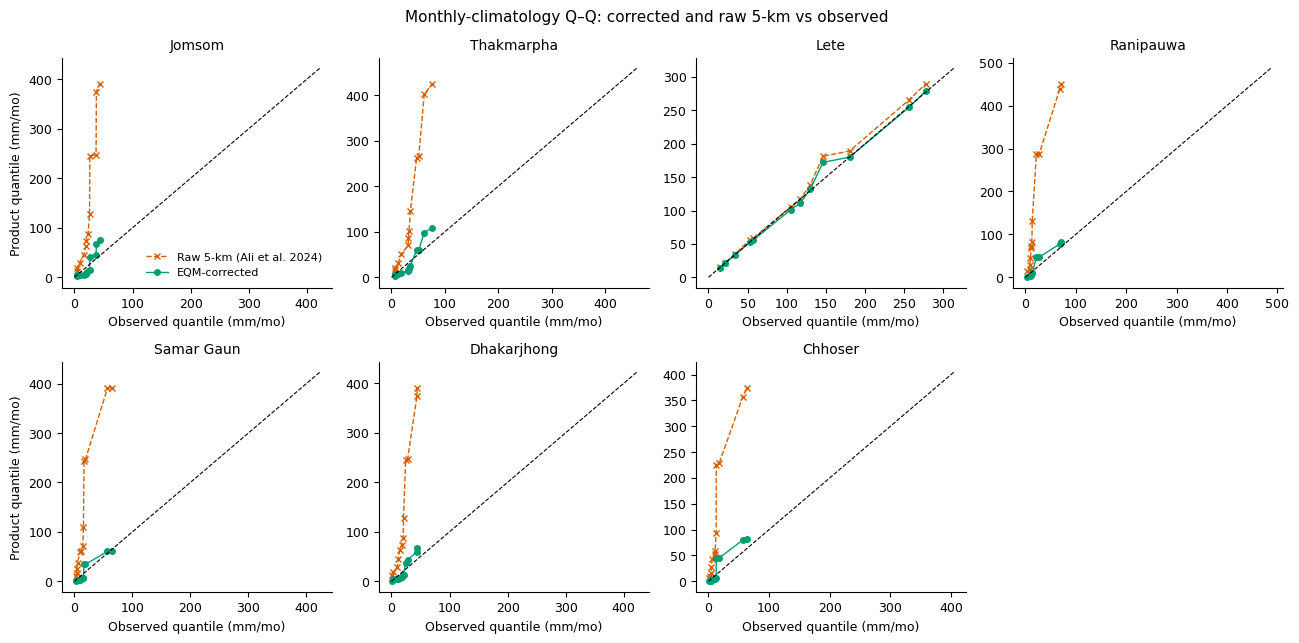

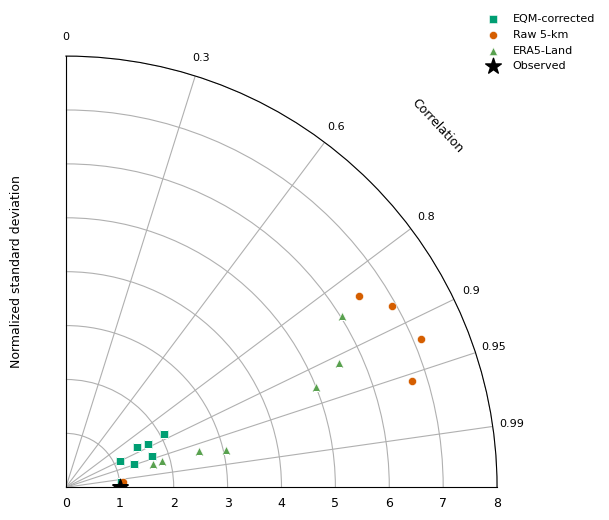

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

stations7 = list(obs_p.columns)

# ---------- Q-Q: monthly climatology quantiles, corrected & raw vs observed
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for ax, sta in zip(axes.ravel(), stations7):
    o = np.sort(obs_p[sta].dropna().values)
    c = np.sort(station["corr_p"][sta].reindex(obs_p.index)
                .where(~obs_p[sta].isna()).dropna().values)
    lim = max(o.max(), c.max()) * 1.08
    if raw_p is not None:
        r = np.sort(raw_p[sta].reindex(obs_p.index)
                    .where(~obs_p[sta].isna()).dropna().values)
        ax.plot(o, r, "x--", color="#D55E00", ms=5, lw=1,
                label="Raw 5-km (Ali et al. 2024)")
        lim = max(lim, r.max() * 1.08)
    ax.plot(o, c, "o-", color="#009E73", ms=4, lw=1, label="EQM-corrected")
    ax.plot([0, lim], [0, lim], "k--", lw=0.8)
    ax.set_title(sta, fontsize=10)
    ax.set_xlabel("Observed quantile (mm/mo)")
axes[0, 0].set_ylabel("Product quantile (mm/mo)")
axes[1, 0].set_ylabel("Product quantile (mm/mo)")
axes[1, 3].axis("off")
axes[0, 0].legend(fontsize=8, frameon=False)
fig.suptitle("Monthly-climatology Q\u2013Q: corrected and raw 5-km vs observed",
             fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "Supplementary_Figure_S5_QQ.png"),
            dpi=300, bbox_inches="tight")
print("saved Supplementary_Figure_S5_QQ.png")

# ---------- Taylor diagram: corrected / raw / ERA5-Land vs observed
def taylor_stats(mod, obs):
    ok = ~np.isnan(mod) & ~np.isnan(obs)
    m, o = mod[ok], obs[ok]
    return np.corrcoef(m, o)[0, 1], m.std(), o.std()

fig = plt.figure(figsize=(6, 5.6))
ax = fig.add_subplot(111, projection="polar")
ax.set_thetamin(0); ax.set_thetamax(90)
corrs = np.array([0, .3, .6, .8, .9, .95, .99])
ax.set_xticks(np.arccos(corrs))
ax.set_xticklabels([f"{c:g}" for c in corrs], fontsize=8)
maxr = 0
prods = [("EQM-corrected", station["corr_p"], "#009E73", "s"),
         ("ERA5-Land", el_precip, "#59A14F", "^")]
if raw_p is not None:
    prods.insert(1, ("Raw 5-km", raw_p, "#D55E00", "o"))
for label, df, col, mk in prods:
    for sta in stations7:
        r, sm, so = taylor_stats(df[sta].values, obs_p[sta].values)
        ax.scatter(np.arccos(np.clip(r, 0, 1)), sm / so, s=34, color=col,
                   marker=mk, edgecolor="white", lw=0.4,
                   label=label if sta == stations7[0] else None, zorder=4)
        maxr = max(maxr, sm / so)
ax.scatter(0, 1, s=140, color="k", marker="*", zorder=5, label="Observed")
ax.set_rmax(min(maxr * 1.12, 8))
ax.set_ylabel("Normalized standard deviation", labelpad=28, fontsize=9)
ax.text(np.radians(42), ax.get_rmax() * 1.16, "Correlation",
        rotation=-47, ha="center", fontsize=9)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.12), fontsize=8,
          frameon=False)
fig.savefig(os.path.join(OUT_DIR, "Supplementary_Figure_S6_Taylor.png"),
            dpi=300, bbox_inches="tight")
print("saved Supplementary_Figure_S6_Taylor.png")

In [15]:
APHRO_DIR = r"C:\Users\Apechhya Aryal\Desktop\forpaper\code\aphrodite_data"

def load_aphrodite_climatology():
    """APHRO_MA daily 0.25deg precip -> 1981-2014 monthly climatology at stations.
    Handles both NetCDF (V1101/V1101EX_R1 .nc) files."""
    import glob
    files = sorted(glob.glob(os.path.join(APHRO_DIR, "*.nc")))
    if not files:
        print("No APHRODITE files found in", APHRO_DIR, "- see Section 11 notes.")
        return None
    ds = xr.open_mfdataset(files, combine="by_coords")
    pvar = [v for v in ds.data_vars if v.lower() in
            ("precip", "pcp", "rain", "tp", "apcp")][0]
    da = ds[pvar].sel(time=slice("1981", "2014"))
    lat_dim = "latitude" if "latitude" in da.dims else "lat"
    lon_dim = "longitude" if "longitude" in da.dims else "lon"
    mon = da.resample(time="1ME").sum()                 # mm/day -> mm/month
    clim = mon.groupby("time.month").mean("time")
    rec = {}
    for name, m in STATIONS.items():
        rec[name] = clim.sel({lat_dim: m["lat"], lon_dim: m["lon"]},
                             method="nearest").values
    return pd.DataFrame(rec, index=range(1, 13))

def load_aphrodite_climatology():
    import glob
    files = sorted(glob.glob(os.path.join(APHRO_DIR, "*.nc")))
    if not files:
        print("No APHRODITE files found in", APHRO_DIR, "- see Section 11 notes.")
        return None
    print(f"  found {len(files)} files (V1101 + V1101EX_R1 both supported)")
    # Concat along time only (avoids by_coords index requirement in xarray>=3)
    parts = [xr.open_dataset(f) for f in files]
    ds = xr.concat(parts, dim="time", coords="minimal",
                   data_vars="minimal", compat="override").sortby("time")
    _, keep = np.unique(ds["time"].values[::-1], return_index=True)
    ds = ds.isel(time=np.sort(len(ds["time"]) - 1 - keep))   # keep EX_R1 on overlap
    pvar = [v for v in ds.data_vars if v.lower() in
            ("precip", "pcp", "rain", "tp", "apcp")][0]
    da = ds[pvar].sel(time=slice("1981", "2014"))
    da = da.where(da > -90)                      # APHRODITE undef = -99.9
    lat_dim = "latitude" if "latitude" in da.dims else "lat"
    lon_dim = "longitude" if "longitude" in da.dims else "lon"
    mon = da.resample(time="1ME").sum()          # mm/day -> mm/month
    clim = mon.groupby("time.month").mean("time")
    rec = {}
    for name, m in STATIONS.items():
        rec[name] = clim.sel({lat_dim: m["lat"], lon_dim: m["lon"]},
                             method="nearest").values
    return pd.DataFrame(rec, index=range(1, 13))


# ---- APHRO_TAVE V1808: gauge-based daily Tave (APHRODITE has NO Tmax/Tmin) ----
# Download APHRO_TAVE_MA V1808 (0.25deg, 1961-2015) from the same APHRODITE
# site into aphrodite_tave/ . Compared against observed Tave=(Tmax+Tmin)/2.
APHRO_TAVE_DIR = r"C:\Users\Apechhya Aryal\Desktop\forpaper\code\aphrodite_tave"

def load_aphro_tave():
    import glob
    files = sorted(glob.glob(os.path.join(APHRO_TAVE_DIR, "*.nc")))
    if not files:
        print("No APHRO_TAVE files in", APHRO_TAVE_DIR, "- skipping temperature.")
        return None
    ds = xr.open_mfdataset(files, combine="by_coords")
    tvar = [v for v in ds.data_vars if v.lower() in ("tave","temp","tavg","t2m")][0]
    da = ds[tvar].sel(time=slice("1981", "2014"))
    lat_dim = "latitude" if "latitude" in da.dims else "lat"
    lon_dim = "longitude" if "longitude" in da.dims else "lon"
    clim = da.groupby("time.month").mean("time")
    rec = {}
    for name in obs_tmean.columns:          # observing stations only
        m = STATIONS[name]
        v = clim.sel({lat_dim: m["lat"], lon_dim: m["lon"]}, method="nearest")
        rec[name] = v.values
    out = pd.DataFrame(rec, index=range(1, 13))
    # height-adjust 0.25deg cell to station elevation with the station lapse rate
    # (APHRO_TAVE grid orography differs from valley floor like ERA5-Land does;
    #  V1808 is gauge-interpolated so the offset is smaller, but report both)
    return out

aph_t = load_aphro_tave()
if aph_t is not None:
    metrics_aph_t = compute_temp_metrics(aph_t, obs_tmean, "APHRO_TAVE")
    print(metrics_aph_t.to_string(index=False))
    metrics_aph_t.to_csv(os.path.join(OUT_DIR, "aphro_tave_metrics.csv"), index=False)


Station    Product  Bias_degC  RMSE_degC     R2  Mean_ERA5L  Mean_Sta
 Jomsom APHRO_TAVE     -10.03      10.04 0.9967        1.52     11.56
   Lete APHRO_TAVE      -2.74       2.79 0.9965        9.01     11.75
